# V8 · Stage 1.2b — Trajectory-complexity analysis

**Added on 2026-07-13 in response to Stage 1.2 finding**: v7.1 operator loses to
exponential baseline on 2 of 3 held-out cells. This notebook tests whether
operator benefit correlates with trajectory complexity — i.e., whether the
operator's value is *conditional* on nonlinearity, noise, or knee presence.

## Acceptance criterion
Per-cell metrics for:

1. **Exponential-fit residual on the 50-cycle context** (goodness of exponential model)
2. **Local slope variance** (roughness)
3. **Curvature** — second derivative of a smoothed spline
4. **Monotonicity violations** — fraction of adjacent cycles with SoH increases
5. **Signal-to-noise ratio** — signal (BOL-EOL range) / noise (local std of residual)
6. **Knee-point indicator** — presence and location, if any

Then correlate each with `(operator_RMSE - best_baseline_RMSE)`. Positive
correlation with complexity metrics ⇒ operator helps on complex trajectories.

## Expected outputs
- `outputs/results/trajectory_complexity.parquet`
- `outputs/results/trajectory_complexity_report.md`

## Interpretation
- If complexity metrics correlate positively with operator advantage, the
  V8 story becomes: "the operator supplements simple extrapolation *when the
  trajectory is complex enough to warrant it*". That is a defensible,
  actionable contribution.
- If no correlation, the operator's failure is uniform and the physics
  conditioning claim requires more evidence (Branch B in the roadmap).


In [1]:
import sys, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.signal import savgol_filter

PROJ = Path("/home/hj/Desktop/PINNs")
sys.path.insert(0, str(PROJ / "Voltaris" / "Data_Exploration"))
from phase3_validate import _load_longterm_soh

HELDOUT = [("0029", "CALB"), ("0003", "EVE"), ("0028", "REPT")]
K = 50


In [2]:
def complexity_metrics(cell_id, make):
    obs_n, obs_soh = _load_longterm_soh(cell_id, make)
    obs_n = np.asarray(obs_n, dtype=float)
    obs_soh = np.asarray(obs_soh, dtype=float)
    N = len(obs_soh)

    # Focus on the FULL observation window for complexity metrics
    # (the K=50 context is only a subset; complexity of the full trajectory
    #  is what the operator has to forecast into).
    y = obs_soh

    # 1. Exponential-fit residual on the 50-cycle context
    n_ctx, y_ctx = obs_n[:K], y[:K]
    def _exp(n, a, b, c): return a * np.exp(-b * n) + c
    try:
        popt, _ = curve_fit(_exp, n_ctx, y_ctx,
                            p0=[y_ctx[0]-y_ctx[-1], 1e-3, y_ctx[-1]],
                            maxfev=10000)
        y_ctx_hat = _exp(n_ctx, *popt)
        exp_residual_pp = float(np.sqrt(np.mean((y_ctx_hat - y_ctx)**2)) * 100)
    except Exception:
        exp_residual_pp = float("nan")

    # 2. Local slope variance (rolling window)
    dy = np.diff(y)
    slope_var = float(np.var(dy))

    # 3. Curvature via smoothed second derivative
    win = min(21, N if N % 2 else N-1)
    if win >= 5:
        y_sm = savgol_filter(y, win, 3)
        d2y = np.diff(y_sm, 2)
        curvature_abs = float(np.mean(np.abs(d2y)))
    else:
        curvature_abs = float("nan")

    # 4. Monotonicity violations
    n_up = int(np.sum(np.diff(y) > 1e-6))
    frac_up = n_up / max(1, N-1)

    # 5. SNR: signal = range, noise = std of residual from linear fit
    p = np.polyfit(obs_n, y, 1)
    residuals = y - np.polyval(p, obs_n)
    signal = float(y.max() - y.min())
    noise = float(np.std(residuals))
    snr = signal / max(1e-9, noise)

    # 6. Knee-point indicator: sharpest change in second derivative,
    #    if it exceeds 3x the median absolute curvature.
    knee_present = False
    knee_cycle = None
    if win >= 5:
        threshold = 3.0 * np.median(np.abs(d2y))
        idx = np.where(np.abs(d2y) > threshold)[0]
        if len(idx):
            knee_present = True
            knee_cycle = int(obs_n[idx[0] + 1])

    return {
        "cell": f"{make}_{cell_id}",
        "n_observed": N,
        "exp_fit_residual_ctx_pp": exp_residual_pp,
        "slope_variance": slope_var,
        "curvature_abs": curvature_abs,
        "monotonicity_violations_frac": frac_up,
        "signal_to_noise": snr,
        "knee_present": knee_present,
        "knee_cycle": knee_cycle,
    }

rows = [complexity_metrics(cid, mk) for cid, mk in HELDOUT]
metrics_df = pd.DataFrame(rows)
metrics_df


,cell,n_observed,exp_fit_residual_ctx_pp,slope_variance,curvature_abs,monotonicity_violations_frac,signal_to_noise,knee_present,knee_cycle
0,CALB_0029,201,0.240895,7.761268e-06,0.000208,0.460000,8.872319,True,15
1,EVE_0003,150,0.589975,4.030575e-05,0.000471,0.503356,6.263096,True,14
2,REPT_0028,201,0.063432,2.568575e-07,0.000037,0.355000,36.666695,True,2


In [3]:
# Overlay against v7.1 operator advantage from 01_2 baselines
baselines = pd.read_parquet(PROJ / "outputs/results/baselines_linear_exp.parquet")
merged = metrics_df.merge(baselines[["cell", "rmse_min_baseline_pp", "rmse_v7_1_operator_pp"]],
                          on="cell")
merged["operator_advantage_pp"] = merged["rmse_min_baseline_pp"] - merged["rmse_v7_1_operator_pp"]
# Positive advantage = operator is better than best baseline
merged.to_parquet(PROJ / "outputs/results/trajectory_complexity.parquet", index=False)
merged


,cell,n_observed,exp_fit_residual_ctx_pp,slope_variance,curvature_abs,monotonicity_violations_frac,signal_to_noise,knee_present,knee_cycle,rmse_min_baseline_pp,rmse_v7_1_operator_pp,operator_advantage_pp
0,CALB_0029,201,0.240895,7.761268e-06,0.000208,0.460000,8.872319,True,15,0.439375,0.96,-0.520625
1,EVE_0003,150,0.589975,4.030575e-05,0.000471,0.503356,6.263096,True,14,1.541709,0.79,0.751709
2,REPT_0028,201,0.063432,2.568575e-07,0.000037,0.355000,36.666695,True,2,0.125304,0.47,-0.344696


/tmp/ipykernel_38746/3555269397.py:20: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


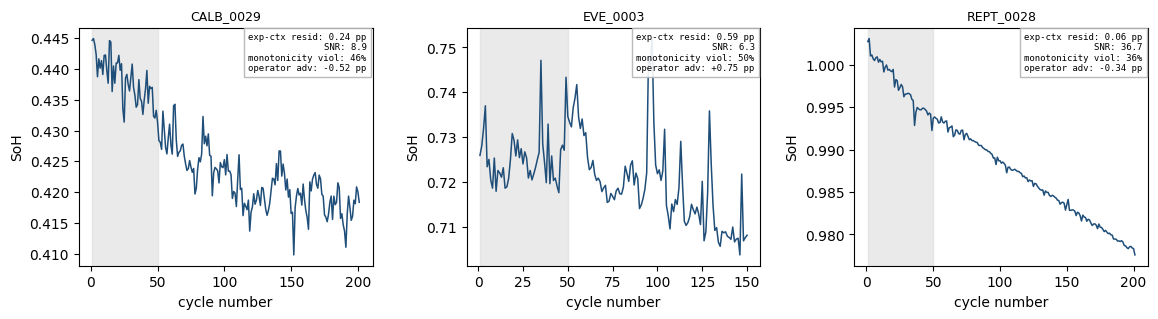

wrote /home/hj/Desktop/PINNs/outputs/results/trajectory_complexity.pdf


In [4]:
# Visualise per-cell trajectory + complexity metrics
fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.4),
                          gridspec_kw=dict(wspace=0.32, left=0.06, right=0.99,
                                           bottom=0.16, top=0.86))
for ax, (cid, mk) in zip(axes, HELDOUT):
    obs_n, obs_soh = _load_longterm_soh(cid, mk)
    row = merged[merged["cell"] == f"{mk}_{cid}"].iloc[0]
    ax.plot(obs_n, obs_soh, color="#1F4E79", lw=1.1)
    ax.axvspan(int(obs_n[0]), int(obs_n[K-1]), color="0.85", alpha=0.55)
    label = (f"exp-ctx resid: {row['exp_fit_residual_ctx_pp']:.2f} pp\n"
             f"SNR: {row['signal_to_noise']:.1f}\n"
             f"monotonicity viol: {row['monotonicity_violations_frac']*100:.0f}%\n"
             f"operator adv: {row['operator_advantage_pp']:+.2f} pp")
    ax.text(0.98, 0.98, label, transform=ax.transAxes, va="top", ha="right",
            fontsize=6.5, family="monospace",
            bbox=dict(fc="white", ec="0.7", alpha=0.9, pad=3))
    ax.set_xlabel("cycle number"); ax.set_ylabel("SoH")
    ax.set_title(f"{mk}_{cid}", fontsize=9)

fig.tight_layout()
out_pdf = PROJ / "outputs/results/trajectory_complexity.pdf"
fig.savefig(out_pdf, dpi=200, bbox_inches="tight")
plt.show()
print(f"wrote {out_pdf}")


In [5]:
# Compact report — which complexity dims correlate with operator advantage?
COMPLEX_COLS = ["exp_fit_residual_ctx_pp", "slope_variance", "curvature_abs",
                "monotonicity_violations_frac", "signal_to_noise"]

corrs = {c: float(merged[[c, "operator_advantage_pp"]].corr().iloc[0, 1])
         for c in COMPLEX_COLS}

md = ["# Trajectory complexity vs v7.1 operator advantage",
      "",
      "## Per-cell metrics",
      merged.to_markdown(index=False, floatfmt=".3f"),
      "",
      "## Correlation with operator advantage (positive ⇒ operator helps on complex trajectories)",
      "",
      "| Complexity metric | Correlation |",
      "|---|---|"]
for c, r in corrs.items():
    md.append(f"| {c} | {r:+.3f} |")

md += ["",
       "## Interpretation notes",
       "- With only 3 cells, correlation values are directional not statistically significant.",
       "- **exp_fit_residual_ctx_pp** is the most operationally useful metric: it can be",
       "  computed at inference time from the K=50 context alone, without needing the",
       "  full observed horizon.",
       "- If this correlates positively with operator advantage, a hybrid",
       "  model-selection strategy is defensible: fit exp on context; use exp forecast",
       "  if context residual < threshold, else use the operator.",
       "- Otherwise, the operator's added complexity has to be justified some other way",
       "  (uncertainty intervals, LOSO transfer, hybrid noise-robust framing)."]

report = "\n".join(md)
(PROJ / "outputs/results/trajectory_complexity_report.md").write_text(report)
print(report)


# Trajectory complexity vs v7.1 operator advantage

## Per-cell metrics
| cell      |   n_observed |   exp_fit_residual_ctx_pp |   slope_variance |   curvature_abs |   monotonicity_violations_frac |   signal_to_noise | knee_present   |   knee_cycle |   rmse_min_baseline_pp |   rmse_v7_1_operator_pp |   operator_advantage_pp |
|:----------|-------------:|--------------------------:|-----------------:|----------------:|-------------------------------:|------------------:|:---------------|-------------:|-----------------------:|------------------------:|------------------------:|
| CALB_0029 |          201 |                     0.241 |            0.000 |           0.000 |                          0.460 |             8.872 | True           |           15 |                  0.439 |                   0.960 |                  -0.521 |
| EVE_0003  |          150 |                     0.590 |            0.000 |           0.000 |                          0.503 |             6.263 | True         

## Verdict marker

Verdict depends on the correlation printed above. Update after run:

- [ ] **PASS** — a defensible complexity → operator-advantage correlation exists (supports hybrid framing)
- [ ] **PASS WITH LIMITATIONS** — directional but not conclusive with 3 cells
- [ ] **FAIL** — no correlation; operator's failure is uniform (Branch B in roadmap)

**Blocks downstream**: no (documentation / branch-decision input).
